# Wavenet

In [5]:
import numpy as np
import pywt
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import datasets, transforms
from sktime.datasets import load_from_tsfile_to_dataframe
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
import torch.nn.functional as F
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import json
import os
os.environ["WANDB_API_KEY"] = "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"
import wandb


In [6]:
def get_resnext_binary_model():
    weights = models.ResNeXt50_32X4D_Weights.DEFAULT
    model = models.resnext50_32x4d(weights=weights)

    # 1. Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # 2. Unlock ONLY the final bottleneck block of Layer 4
    # This significantly reduces the number of trainable parameters
    for param in model.layer4[2].parameters():
        param.requires_grad = True

    # 3. Replace and unlock the classification head
    # Adding Dropout here too as a secondary defense against overfitting
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, 1),
        nn.Sigmoid()
    )
    
    for param in model.fc.parameters():
        param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"ResNeXt initialized. ONLY layer4[2] + FC unlocked.")
    print(f"Total trainable parameters: {trainable_params:,}")
        
    return model

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleSignalCNN(nn.Module):
    def __init__(self):
        super(SimpleSignalCNN, self).__init__()
        
        # Layer 1: Input 3 x 224 x 224 -> Output 16 x 112 x 112
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        # Layer 2: Output 32 x 56 x 56
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        # Layer 3: Output 64 x 28 x 28
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Layer 4: Output 128 x 14 x 14
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Classification Head
        # After 4 pools, a 224x224 image becomes 14x14
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Flattens to 128 channels
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        
        return self.fc(x)

def get_resnext_binary_model():
    model = SimpleSignalCNN()
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Basic CNN initialized. Trainable parameters: {trainable_params:,}")
    return model

In [8]:
import copy
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
import wandb

def model_fit_resnext(train_loader, test_loader, device):
    # Log the strategy: Single LR with restricted backbone
    wandb.init(project="wavenet-project", config={
        "model": 'resNext50',
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "patience": 20,
        "label_smoothing": 0.1
    })
    
    model = get_resnext_binary_model().to(device)
    
    # We use BCELoss, but we will manually apply smoothing
    criterion = nn.BCELoss()

    # SINGLE LR for all trainable parameters (layer4[2] + FC)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3, 
        weight_decay=1e-4
    )
    
    scheduler = StepLR(optimizer, step_size=8, gamma=0.3)
    
    epochs = 100 
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    patience = 20  
    counter = 0    
    
    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
    
        for x, y in train_loader:
            x, y = x.to(device), y.to(device).float().unsqueeze(1)
            
            # --- Label Smoothing ---
            # Changes 0 -> 0.05 and 1 -> 0.95
            y_smoothed = y * 0.9 + 0.05
            
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y_smoothed)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * x.size(0)
            preds = (outputs > 0.5).float()
            correct_train += (preds == y).sum().item() # Accuracy vs real labels
            total_train += y.size(0)
    
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()
        
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        log_contents = {
            "epoch": epoch,
            "train/loss": epoch_train_loss,
            "train/accuracy": epoch_train_acc,
            "lr": current_lr
        }
        
        # --- VALIDATION PHASE ---
        if test_loader is not None:
            accuracy, recall, precision, f1, auc = evaluate_metrics(model, test_loader, device)
            
            log_contents.update({
                "test/accuracy": accuracy,
                "test/f1": f1,
                "test/auc": auc
            })

            if accuracy > best_acc:
                best_acc = accuracy
                best_model_wts = copy.deepcopy(model.state_dict())
                wandb.run.summary["best_accuracy"] = best_acc
                counter = 0 
                print(f"Epoch {epoch}: New best accuracy {best_acc:.4f}")
            else:
                counter += 1

        wandb.log(log_contents)

        if counter >= patience:
            print(f"Early stopping triggered. No improvement in {patience} epochs.")
            break

    model.load_state_dict(best_model_wts)
    wandb.finish()
    return model

In [9]:
def evaluate_metrics(model, dataloader, device, threshold=0.5):
    """
    Evaluates binary classification metrics for the CWT-based model.
    """
    model.eval()

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            # Binary targets for BCELoss/Scikit-learn
            y_true = y.to(device).float().view(-1)
            
            outputs = model(x)

            # Extract probabilities (since the model ends with Sigmoid)
            probs = outputs.view(-1).float()
            preds = (probs >= threshold).float()

            y_proba_all.append(probs.cpu())
            y_true_all.append(y_true.cpu())
            y_pred_all.append(preds.cpu())

    # Concatenate all batches
    y_test = torch.cat(y_true_all).numpy()
    y_pred = torch.cat(y_pred_all).numpy()
    y_proba = torch.cat(y_proba_all).numpy()

    # Calculate Standard Binary Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        # Prevents crashing if the batch only contains one class
        auc = float("nan")

    return accuracy, recall, precision, f1, auc

In [10]:
def cwt_transform(signal, wavelet='morl', scales=np.arange(1, 21)):
    signal = np.array(signal)
    coefs, _ = pywt.cwt(signal, scales, wavelet)
    return coefs  # shape: [scale, time]

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch.utils.data import Dataset
import torch.nn.functional as F
from tqdm import tqdm

class CWTTimeSeriesDataset(Dataset):
    def __init__(self, x_df, y_list, wavelet, scales, new_size=(224, 224)):
        self.samples = []
        self.labels = []
        
        # Get the 'jet' colormap function
        self.cmap = cm.get_cmap('jet')

        for i in tqdm(range(len(x_df)), desc="Jet Colorizing CWT"):
            ts = x_df.iloc[i].iloc[0]
            img = cwt_transform(ts, wavelet, scales) 
            
            # 1. Convert to Tensor [1, H, W]
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
            
            # 2. Cheapest Resize: 'nearest'
            # Doing this BEFORE colorization is significantly more memory efficient
            img_resized = F.interpolate(
                img_tensor.unsqueeze(0), 
                size=new_size, 
                mode='nearest'
            ).squeeze() # shape: [new_h, new_w]
            
            # 3. Normalize to [0, 1] for colormapping
            img_min, img_max = img_resized.min(), img_resized.max()
            img_norm = (img_resized - img_min) / (img_max - img_min + 1e-8)
            
            # 4. Apply Jet Color Map
            # cmap returns (H, W, 4) including alpha; we take the first 3 (RGB)
            img_jet = self.cmap(img_norm.numpy())[:, :, :3] 
            
            # 5. Convert back to Tensor and permute to [C, H, W] for PyTorch
            img_final = torch.tensor(img_jet, dtype=torch.float32).permute(2, 0, 1)

            self.samples.append(img_final)
            self.labels.append(int(y_list[i]))

    def plot(self, idx):
        img_tensor = self.samples[idx]
        # Permute for matplotlib: [C, H, W] -> [H, W, C]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        
        plt.figure(figsize=(6, 6))
        plt.imshow(img_np)
        plt.title(f"Sample {idx} - Jet Colorized (Nearest)")
        plt.axis('off')
        plt.show()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

In [34]:
# Plot image
dataset_prefix = "data/data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data/TokenItaly_vers0/"
file_path_train = dataset_prefix + "TokenItaly_vers0_TRAIN.ts"
file_path_test = dataset_prefix + "/TokenItaly_vers0_TEST.ts"

x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

wavelet = 'morl'
scales = np.arange(1, 21) # 20 scales (height)

train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales)
    


/tmp/ipykernel_1637/1295017911.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.cmap = cm.get_cmap('jet')
Jet Colorizing CWT: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 4970/4970 [00:03<00:00, 1257.53it/s]


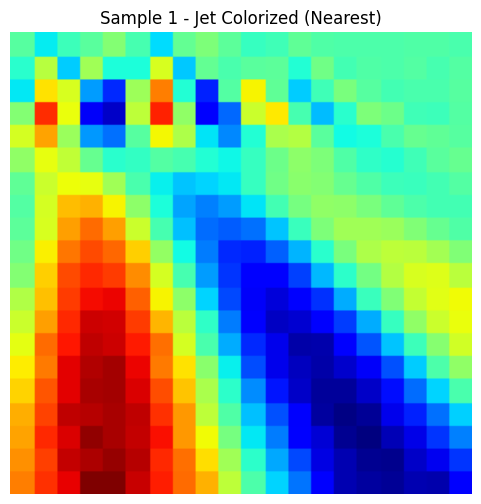

In [12]:
train_dataset.plot(1)

In [12]:
def wl_train_and_test(data_name):
    wavelet = 'morl'
    scales = np.arange(1, 21) # 20 scales (height)
    
    # --- 1. Load Data ---
    data_id = data_name[4:6]
    file_path_train = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TRAIN.ts"
    file_path_test = f"data/{data_name}/TokenItaly_vers0/TokenItaly_vers0_TEST.ts"

    x_train, y_train = load_from_tsfile_to_dataframe(file_path_train)
    x_test, y_test = load_from_tsfile_to_dataframe(file_path_test)

    # --- 2. Create and Resize Datasets ---
    train_dataset = CWTTimeSeriesDataset(x_train, y_train, wavelet, scales)
    val_dataset = CWTTimeSeriesDataset(x_test, y_test, wavelet, scales)
        
    # Lower batch size (16) is usually safer for ResNeXt on consumer GPUs
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device} for training on {data_name}')

    # --- 3. Train Model ---
    # We only return the model now, as requested
    model = model_fit_resnext(train_loader, val_loader, device)
    
    # --- 4. Evaluate ---
    accuracy, recall, precision, f1, auc = evaluate_metrics(model, val_loader, device)
    
    result_dict = {
        "data_id" : data_id,
        "data_name" : data_name,
        "model" : "ResNeXt50_TransferLearning-v2",
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1-score" : f1,
        "ROC-AUC score" : auc
    }

    return result_dict

In [13]:
# image experimentation

In [14]:
json_path = 'results.json'
csv_path = 'results.csv'

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        all_results = json.load(f)
else:
    all_results = []

data_root_path = 'data'

# Define target datasets to run (can be modified)
target_ids = ['10']

all_data_names = sorted([
    name for name in os.listdir(data_root_path)
    if os.path.isdir(os.path.join(data_root_path, name)) and name.startswith('data')
])

# Filter datasets to only include those in target_ids
data_names = []
for name in all_data_names:
    # Check if name matches data{id} or data{id}_...
    for tid in target_ids:
        if name == f"data{tid}" or name.startswith(f"data{tid}_"):
            data_names.append(name)
            break




c = 0
for data_name in data_names:
    result_dict = wl_train_and_test(data_name)
    all_results.append(result_dict)
    c += 1
    print(data_name)

with open(json_path, 'w') as f:
    json.dump(all_results, f, indent=2)


df = pd.DataFrame(all_results)
df.to_csv(csv_path, index=False)

print(f"{c} data is trained and results added to the files...")

/tmp/ipykernel_2340/1295017911.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.cmap = cm.get_cmap('jet')
Jet Colorizing CWT: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 4970/4970 [00:04<00:00, 1084.69it/s]


Using device: cuda for training on data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Basic CNN initialized. Trainable parameters: 98,049


Training:   1%|█▏                                                                                                                         | 1/100 [00:07<11:42,  7.09s/it]

...

Epoch 31: New best accuracy 0.7306


Training:  51%|██████████████████████████████████████████████████████████████▏                                                           | 51/100 [05:32<05:19,  6.52s/it]

Early stopping triggered. No improvement in 20 epochs.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▅▅▅▆▆▆▅▆▆▄▆▇▆▇▇█▇▇▇█▇▇█████████████████
test/auc,▁▃▃▃▄▄▅▆▆▆▆▆▇▇▇▇▇███████████████████████
test/f1,▁▇▇▆▇▇▇▇▆▇▇█▇▇▇▇██▇▇▇▇▇▇██▇▇█▇▇▇▇▇▇▇▇▇▇▇
train/accuracy,▁▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇█████████▇████
train/loss,█▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_accuracy,0.73058
epoch,51
lr,0.0
test/accuracy,0.72978


data10_IC1_FM_label_wl_20_pw_0_unwo_dropped_1_1_ratio_full_data
1 data is trained and results added to the files...
